In [57]:
import pandas as pd 
import numpy as np

In [58]:
transaction_data = pd.read_csv("data/transaction_data.csv")
product = pd.read_csv("data/product.csv")
hh_demographic = pd.read_csv("data/hh_demographic.csv")
campaign_table = pd.read_csv("data/campaign_table.csv")
campaign_desc = pd.read_csv("data/campaign_desc.csv")
coupon = pd.read_csv("data/coupon.csv")
coupon_redempt = pd.read_csv("data/coupon_redempt.csv")

In [59]:
transaction_data.shape

(2595732, 12)

In [60]:
transaction_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2595732 entries, 0 to 2595731
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   TRANS_TIME         int64  
 9   WEEK_NO            int64  
 10  COUPON_DISC        float64
 11  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(8)
memory usage: 237.6 MB


In [61]:
transaction_data.isnull().sum()

household_key        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QUANTITY             0
SALES_VALUE          0
STORE_ID             0
RETAIL_DISC          0
TRANS_TIME           0
WEEK_NO              0
COUPON_DISC          0
COUPON_MATCH_DISC    0
dtype: int64

transaction_data.duplicated().sum()

La tabla transacciones no tiene valores nulos ni filas duplicadas en sus 
2,595,732 registros. Los datos llegan completos a nivel de transacción, 
por lo que no se requiere imputación ni deduplicación en esta tabla.

In [62]:
transaction_data.describe()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
count,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06
mean,1.271953e+03,3.402620e+10,3.887562e+02,2.891435e+06,1.004286e+02,3.104120e+00,3.142673e+03,-5.387054e-01,1.561586e+03,5.622150e+01,-1.641600e-02,-2.918564e-03
std,7.260660e+02,4.711649e+09,1.897210e+02,3.837404e+06,1.153436e+03,4.182274e+00,8.937113e+03,1.249191e+00,3.998378e+02,2.710223e+01,2.168410e-01,3.969004e-02
min,1.000000e+00,2.698485e+10,1.000000e+00,2.567100e+04,0.000000e+00,0.000000e+00,1.000000e+00,-1.800000e+02,0.000000e+00,1.000000e+00,-5.593000e+01,-7.700000e+00
25%,6.560000e+02,3.040805e+10,2.290000e+02,9.174590e+05,1.000000e+00,1.290000e+00,3.300000e+02,-6.900000e-01,1.308000e+03,3.300000e+01,0.000000e+00,0.000000e+00
50%,1.272000e+03,3.276081e+10,3.900000e+02,1.028816e+06,1.000000e+00,2.000000e+00,3.720000e+02,-1.000000e-02,1.613000e+03,5.600000e+01,0.000000e+00,0.000000e+00
75%,1.913000e+03,4.012685e+10,5.530000e+02,1.133018e+06,1.000000e+00,3.490000e+00,4.220000e+02,0.000000e+00,1.843000e+03,8.000000e+01,0.000000e+00,0.000000e+00
max,2.500000e+03,4.230536e+10,7.110000e+02,1.831630e+07,8.963800e+04,8.400000e+02,3.428000e+04,3.990000e+00,2.359000e+03,1.020000e+02,0.000000e+00,0.000000e+00


In [64]:
(transaction_data['QUANTITY'] < 0).sum()

np.int64(0)

In [65]:
(transaction_data['SALES_VALUE'] < 0).sum()  

np.int64(0)

In [66]:
(transaction_data['RETAIL_DISC'] < 0).sum()   

np.int64(1303026)

QUANTITY y SALES_VALUE no presentan valores negativos, pero RETAIL_DISC sí: 
1,303,026 transacciones (≈50% del total) tienen un descuento aplicado, 
registrado con signo negativo respecto al precio de lista. SALES_VALUE 
representa el precio pagado por el cliente, no el precio de lista original.

In [67]:
hh_demographic.shape

(801, 8)

In [68]:
transaction_data['household_key'].nunique()

2500

solo 801 de los 2,500 hogares (32%) tienen datos demográficos disponibles 
en hh_demographic. cualquier análisis por edad, ingreso o tamaño de hogar 
solo puede reportarse sobre este subconjunto del 32%, y no debe extrapolarse 
al resto de la base de clientes.

In [69]:
product.info()

<class 'pandas.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   PRODUCT_ID            92353 non-null  int64
 1   MANUFACTURER          92353 non-null  int64
 2   DEPARTMENT            92353 non-null  str  
 3   BRAND                 92353 non-null  str  
 4   COMMODITY_DESC        92353 non-null  str  
 5   SUB_COMMODITY_DESC    92353 non-null  str  
 6   CURR_SIZE_OF_PRODUCT  92353 non-null  str  
dtypes: int64(2), str(5)
memory usage: 4.9 MB


In [71]:
product.isnull().sum()

PRODUCT_ID              0
MANUFACTURER            0
DEPARTMENT              0
BRAND                   0
COMMODITY_DESC          0
SUB_COMMODITY_DESC      0
CURR_SIZE_OF_PRODUCT    0
dtype: int64

In [70]:
product.duplicated().sum()

np.int64(0)

In [72]:
product['DEPARTMENT'].nunique()

44

In [73]:
product['DEPARTMENT'].value_counts()

DEPARTMENT
GROCERY            39021
DRUG GM            31529
PRODUCE             3118
COSMETICS           3011
NUTRITION           2914
MEAT                2544
MEAT-PCKGD          2427
DELI                2354
PASTRY              2149
FLORAL               938
SEAFOOD-PCKGD        563
MISC. TRANS.         490
SPIRITS              377
SEAFOOD              369
GARDEN CENTER        128
RESTAURANT           102
MISC SALES TRAN       88
SALAD BAR             48
COUP/STR & MFG        39
TRAVEL & LEISUR       28
FROZEN GROCERY        23
KIOSK-GAS             16
                      15
CHEF SHOPPE           14
RX                     9
CNTRL/STORE SUP        4
GM MERCH EXP           3
TOYS                   3
DAIRY DELI             3
VIDEO RENTAL           3
POSTAL CENTER          3
GRO BAKERY             2
CHARITABLE CONT        2
PROD-WHS SALES         2
DELI/SNACK BAR         2
AUTOMOTIVE             2
PHOTO                  2
VIDEO                  2
ELECT &PLUMBING        1
MEAT-WHSE     

In [74]:
product[product['DEPARTMENT'] == '']

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT


In [75]:
(product['DEPARTMENT'] == '').sum()

np.int64(0)

In [76]:
hh_demographic.info()

<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   classification_1   801 non-null    str  
 1   classification_2   801 non-null    str  
 2   classification_3   801 non-null    str  
 3   HOMEOWNER_DESC     801 non-null    str  
 4   classification_5   801 non-null    str  
 5   classification_4   801 non-null    str  
 6   KID_CATEGORY_DESC  801 non-null    str  
 7   household_key      801 non-null    int64
dtypes: int64(1), str(7)
memory usage: 50.2 KB


In [77]:
hh_demographic.isnull().sum()

classification_1     0
classification_2     0
classification_3     0
HOMEOWNER_DESC       0
classification_5     0
classification_4     0
KID_CATEGORY_DESC    0
household_key        0
dtype: int64

In [78]:
hh_demographic.duplicated().sum()

np.int64(0)

In [79]:
hh_demographic['classification_1'].unique()

<StringArray>
['Age Group6', 'Age Group4', 'Age Group2', 'Age Group3', 'Age Group1',
 'Age Group5']
Length: 6, dtype: str

In [80]:
print(hh_demographic['classification_2'].unique())
print(hh_demographic['classification_3'].unique())
print(hh_demographic['classification_4'].unique())
print(hh_demographic['classification_5'].unique())
print(hh_demographic['HOMEOWNER_DESC'].unique())
print(hh_demographic['KID_CATEGORY_DESC'].unique())

<StringArray>
['X', 'Y', 'Z']
Length: 3, dtype: str
<StringArray>
[ 'Level4',  'Level5',  'Level3',  'Level6',  'Level1',  'Level7',  'Level2',
  'Level8',  'Level9', 'Level12', 'Level10', 'Level11']
Length: 12, dtype: str
<StringArray>
['2', '3', '4', '1', '5+']
Length: 5, dtype: str
<StringArray>
['Group5', 'Group4', 'Group3', 'Group6', 'Group2', 'Group1']
Length: 6, dtype: str
<StringArray>
['Homeowner', 'Unknown', 'Renter', 'Probable Renter', 'Probable Owner']
Length: 5, dtype: str
<StringArray>
['None/Unknown', '1', '2', '3+']
Length: 4, dtype: str


In [82]:
hh_demographic = hh_demographic.rename(columns={
    'classification_1': 'AGE_DESC',
    'classification_2': 'MARITAL_STATUS',
    'classification_3': 'INCOME_DESC',
    'classification_4': 'HOUSEHOLD_SIZE_DESC',
    'classification_5': 'HH_COMP_DESC'
})

In [83]:
hh_demographic.columns

Index(['AGE_DESC', 'MARITAL_STATUS', 'INCOME_DESC', 'HOMEOWNER_DESC',
       'HH_COMP_DESC', 'HOUSEHOLD_SIZE_DESC', 'KID_CATEGORY_DESC',
       'household_key'],
      dtype='str')

In [84]:
hh_demographic.columns

Index(['AGE_DESC', 'MARITAL_STATUS', 'INCOME_DESC', 'HOMEOWNER_DESC',
       'HH_COMP_DESC', 'HOUSEHOLD_SIZE_DESC', 'KID_CATEGORY_DESC',
       'household_key'],
      dtype='str')

nota: las columnas de hh_demographic venían anonimizadas como classification_1 
a classification_5. se identificó su significado comparando los valores 
contra la documentación del dataset original y se renombraron a AGE_DESC, 
MARITAL_STATUS, INCOME_DESC, HOUSEHOLD_SIZE_DESC y HH_COMP_DESC.

In [85]:
campaign_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 7208 entries, 0 to 7207
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   DESCRIPTION    7208 non-null   str  
 1   household_key  7208 non-null   int64
 2   CAMPAIGN       7208 non-null   int64
dtypes: int64(2), str(1)
memory usage: 169.1 KB


In [86]:
campaign_table.isnull().sum()

DESCRIPTION      0
household_key    0
CAMPAIGN         0
dtype: int64

In [87]:
campaign_table.duplicated().sum()

np.int64(0)

In [88]:
campaign_table['DESCRIPTION'].unique()

<StringArray>
['TypeA', 'TypeB', 'TypeC']
Length: 3, dtype: str

In [89]:
campaign_desc.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   DESCRIPTION  30 non-null     str  
 1   CAMPAIGN     30 non-null     int64
 2   START_DAY    30 non-null     int64
 3   END_DAY      30 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.1 KB


In [90]:
campaign_desc.isnull().sum()

DESCRIPTION    0
CAMPAIGN       0
START_DAY      0
END_DAY        0
dtype: int64

In [91]:
campaign_desc.duplicated().sum()

np.int64(0)

In [92]:
coupon.info()

<class 'pandas.DataFrame'>
RangeIndex: 124548 entries, 0 to 124547
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   COUPON_UPC  124548 non-null  int64
 1   PRODUCT_ID  124548 non-null  int64
 2   CAMPAIGN    124548 non-null  int64
dtypes: int64(3)
memory usage: 2.9 MB


In [93]:
coupon.isnull().sum()

COUPON_UPC    0
PRODUCT_ID    0
CAMPAIGN      0
dtype: int64

In [94]:
coupon.duplicated().sum()

np.int64(5164)

In [95]:
coupon['COUPON_UPC'].nunique()

1135

In [96]:
coupon[coupon.duplicated(keep=False)].head(10)

,COUPON_UPC,PRODUCT_ID,CAMPAIGN
47,54100010032,34214,27
49,54100010032,34214,27
50,54100010032,34214,27
51,54100010032,34214,27
124,54589314175,48728,27
126,54589314175,48728,27
127,54589314187,48728,27
128,54589314187,48728,27
129,54589314187,48728,27
130,54589314187,48728,27


nota: coupon tiene 5,164 filas exactamente duplicadas (mismo COUPON_UPC, 
PRODUCT_ID y CAMPAIGN repetidos), no solo la relación 1:m esperada. antes 
de mergear contra transaction_data o product, se debe deduplicar con 
coupon.drop_duplicates() para evitar inflar los resultados.

In [97]:
coupon_redempt.info()

<class 'pandas.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   household_key  2318 non-null   int64
 1   DAY            2318 non-null   int64
 2   COUPON_UPC     2318 non-null   int64
 3   CAMPAIGN       2318 non-null   int64
dtypes: int64(4)
memory usage: 72.6 KB


In [98]:
coupon_redempt.isnull().sum()

household_key    0
DAY              0
COUPON_UPC       0
CAMPAIGN         0
dtype: int64

In [99]:
coupon_redempt.duplicated().sum()

np.int64(0)

In [100]:
def reconciliar(antes, despues, metrica, etiqueta=""):
    """Compara filas y total de una metrica antes y despues de una operacion."""
    f0, f1 = len(antes), len(despues)
    m0, m1 = antes[metrica].sum(), despues[metrica].sum()
    ok = bool((f0 == f1) and np.isclose(m0, m1))
    print(f"{'OK' if ok else 'ALERTA'} {etiqueta}")
    print(f"filas: {f0:,} -> {f1:,} ({f1-f0:+,})")
    print(f"{metrica}: {m0:,.2f} -> {m1:,.2f} ({m1-m0:+,.2f})")
    return ok

In [101]:
antes = transaction_data.copy()

transaction_producto = transaction_data.merge(
    product, 
    on='PRODUCT_ID', 
    how='left', 
    validate='m:1'
)

reconciliar(antes, transaction_producto, 'SALES_VALUE', etiqueta='transaction_data + product')

OK transaction_data + product
filas: 2,595,732 -> 2,595,732 (+0)
SALES_VALUE: 8,057,463.08 -> 8,057,463.08 (+0.00)


True

In [102]:
antes = transaction_producto.copy()

transaction_completo = transaction_producto.merge(
    hh_demographic,
    on='household_key',
    how='left',
    validate='m:1'
)

reconciliar(antes, transaction_completo, 'SALES_VALUE', etiqueta='+ hh_demographic')

OK + hh_demographic
filas: 2,595,732 -> 2,595,732 (+0)
SALES_VALUE: 8,057,463.08 -> 8,057,463.08 (+0.00)


True

In [103]:
transaction_completo['DESCUENTO_TOTAL'] = (
    transaction_completo['RETAIL_DISC'] + 
    transaction_completo['COUPON_DISC'] + 
    transaction_completo['COUPON_MATCH_DISC']
)

transaction_completo['PRECIO_LISTA'] = (
    transaction_completo['SALES_VALUE'] - transaction_completo['DESCUENTO_TOTAL']
)

In [104]:
transaction_completo[['SALES_VALUE', 'DESCUENTO_TOTAL', 'PRECIO_LISTA']].describe()

,SALES_VALUE,DESCUENTO_TOTAL,PRECIO_LISTA
count,2.595732e+06,2.595732e+06,2.595732e+06
mean,3.104120e+00,-5.580400e-01,3.662160e+00
std,4.182274e+00,1.280164e+00,4.670147e+00
min,0.000000e+00,-1.800000e+02,-1.000000e-02
25%,1.290000e+00,-7.000000e-01,1.590000e+00
50%,2.000000e+00,-7.000000e-02,2.590000e+00
75%,3.490000e+00,0.000000e+00,3.990000e+00
max,8.400000e+02,3.990000e+00,8.400000e+02


nota: PRECIO_LISTA se calculó como SALES_VALUE - DESCUENTO_TOTAL. la gran 
mayoría de los valores son coherentes (precio de lista ≥ precio pagado), 
salvo un mínimo de -0.01 en casos aislados, probablemente por redondeo en 
transacciones de muy bajo valor.

transaction_completo queda a nivel de producto por transacción (cada fila es un
producto dentro de una canasta). Para el Pareto de gasto y el análisis de campañas
vamos a necesitar agrupar por household_key, así que en esas secciones agregamos
la tabla y lo aclaramos ahí.

In [106]:
antes = coupon.copy()
coupon = coupon.drop_duplicates()
print(f"coupon: {len(antes):,} filas -> {len(coupon):,} filas ({len(coupon)-len(antes):+,})")

coupon: 124,548 filas -> 119,384 filas (-5,164)


In [107]:
antes = campaign_table.copy()

campanas_hogar = campaign_table.merge(
    campaign_desc,
    on='CAMPAIGN',
    how='left',
    validate='m:1'
)

print(f"campaign_table: {len(antes):,} filas -> {len(campanas_hogar):,} filas ({len(campanas_hogar)-len(antes):+,})")
campanas_hogar.head()

campaign_table: 7,208 filas -> 7,208 filas (+0)


,DESCRIPTION_x,household_key,CAMPAIGN,DESCRIPTION_y,START_DAY,END_DAY
0,TypeA,17,26,TypeA,224,264
1,TypeA,27,26,TypeA,224,264
2,TypeA,212,26,TypeA,224,264
3,TypeA,208,26,TypeA,224,264
4,TypeA,192,26,TypeA,224,264


In [111]:
campanas_hogar.head()

,household_key,CAMPAIGN,TIPO_CAMPANA,START_DAY,END_DAY
0,17,26,TypeA,224,264
1,27,26,TypeA,224,264
2,212,26,TypeA,224,264
3,208,26,TypeA,224,264
4,192,26,TypeA,224,264


In [112]:
hogares_con_campana = campanas_hogar['household_key'].unique()
print(f"Hogares que recibieron al menos una campaña: {len(hogares_con_campana):,}")
print(f"Total de hogares en transacciones: {transaction_data['household_key'].nunique():,}")

Hogares que recibieron al menos una campaña: 1,584
Total de hogares en transacciones: 2,500


In [113]:
gasto_por_hogar = transaction_completo.groupby('household_key')['SALES_VALUE'].sum().reset_index()
gasto_por_hogar.columns = ['household_key', 'GASTO_TOTAL']
gasto_por_hogar.head()

,household_key,GASTO_TOTAL
0,1,4330.16
1,2,1954.34
2,3,2653.21
3,4,1200.11
4,5,779.06


In [114]:
gasto_por_hogar['RECIBIO_CAMPANA'] = gasto_por_hogar['household_key'].isin(hogares_con_campana)
gasto_por_hogar['RECIBIO_CAMPANA'].value_counts()

RECIBIO_CAMPANA
True     1584
False     916
Name: count, dtype: int64

De los 2,500 hogares, 1,584 (63%) recibieron al menos una campaña y 916 (37%) no
recibieron ninguna. El gasto total se agregó por hogar sumando SALES_VALUE de toda
la ventana de datos (~2 años), para poder comparar ambos grupos.

In [115]:
comparacion_simple = gasto_por_hogar.groupby('RECIBIO_CAMPANA')['GASTO_TOTAL'].agg(['mean', 'median', 'count'])
comparacion_simple

,mean,median,count
RECIBIO_CAMPANA,,,
False,1028.544094,745.510,916
True,4491.992860,3444.035,1584


In [116]:
primera_campana = campanas_hogar.groupby('household_key')['START_DAY'].min().reset_index()
primera_campana.columns = ['household_key', 'DIA_PRIMERA_CAMPANA']
primera_campana.head()

,household_key,DIA_PRIMERA_CAMPANA
0,1,281
1,2,587
2,3,412
3,4,412
4,6,398


In [117]:
dia_corte = int(primera_campana['DIA_PRIMERA_CAMPANA'].median())
print(f"Día de corte (mediana de la primera campaña): {dia_corte}")

Día de corte (mediana de la primera campaña): 398


In [118]:
antes_del_corte = transaction_completo[transaction_completo['DAY'] < dia_corte]

gasto_pre = antes_del_corte.groupby('household_key')['SALES_VALUE'].sum().reset_index()
gasto_pre.columns = ['household_key', 'GASTO_PRE']

# gasto por día, para que sea comparable (todos los hogares tienen la misma ventana: día 1 a 397)
gasto_pre['GASTO_PRE_DIARIO'] = gasto_pre['GASTO_PRE'] / dia_corte

gasto_pre.head()

,household_key,GASTO_PRE,GASTO_PRE_DIARIO
0,1,2110.36,5.302412
1,2,990.19,2.487915
2,3,2094.30,5.262060
3,4,990.18,2.487889
4,5,505.59,1.270327


In [119]:
gasto_pre = gasto_pre.merge(
    gasto_por_hogar[['household_key', 'RECIBIO_CAMPANA']],
    on='household_key',
    how='left'
)

comparacion_pre = gasto_pre.groupby('RECIBIO_CAMPANA')['GASTO_PRE_DIARIO'].agg(['mean', 'median', 'count'])
comparacion_pre

,mean,median,count
RECIBIO_CAMPANA,,,
False,1.198047,0.823266,914
True,5.725495,4.249698,1583


Comparamos el gasto de los hogares antes de que empezaran las cmpañas (usando el
día 398 como corte). Los que después recibieron campaña ya gastaban $5.73/día en
promedio, contra $1.20/día los que nunca recibieron nada — casi 5 veces más, y esto
es ANTES de que la campaña existiera. O sea que probablemente la tienda le mandó
campaña a la gente que ya compraba mucho, no que la campaña haya hecho que compraran
más. No podemos decir que la campaña "funcionó" sin tener esto en cuenta.


In [121]:
ventas_por_depto = transaction_completo.groupby('DEPARTMENT')['SALES_VALUE'].sum().sort_values(ascending=False)
ventas_por_depto.head(15)

DEPARTMENT
GROCERY            4093814.14
DRUG GM            1055358.03
PRODUCE             557452.11
MEAT                548786.81
KIOSK-GAS           544222.28
MEAT-PCKGD          412436.77
DELI                260866.51
PASTRY              121739.86
MISC SALES TRAN     119960.04
NUTRITION            97669.04
SEAFOOD-PCKGD        63093.62
FLORAL               39653.34
COSMETICS            32360.37
SALAD BAR            30953.30
SEAFOOD              29496.92
Name: SALES_VALUE, dtype: float64

GROCERY domina por completo: $4.09M en ventas, casi 4 veces más que el segundo
(DRUG GM con $1.05M). Entre los dos se llevan la mayoría del negocio. El resto de
departamentos vende bastante menos en comparación.

In [123]:
# los datos van de semana 1 a 102, partimos a la mitad (semana 51)
semana_corte = transaction_completo['WEEK_NO'].max() // 2

ventas_primera_mitad = transaction_completo[transaction_completo['WEEK_NO'] <= semana_corte].groupby('DEPARTMENT')['SALES_VALUE'].sum()
ventas_segunda_mitad = transaction_completo[transaction_completo['WEEK_NO'] > semana_corte].groupby('DEPARTMENT')['SALES_VALUE'].sum()

crecimiento = pd.DataFrame({
    'VENTAS_PRIMERA_MITAD': ventas_primera_mitad,
    'VENTAS_SEGUNDA_MITAD': ventas_segunda_mitad
}).fillna(0)

crecimiento['CRECIMIENTO_PCT'] = (
    (crecimiento['VENTAS_SEGUNDA_MITAD'] - crecimiento['VENTAS_PRIMERA_MITAD']) / crecimiento['VENTAS_PRIMERA_MITAD'] * 100
)

crecimiento.sort_values('CRECIMIENTO_PCT', ascending=False).head(10)

,VENTAS_PRIMERA_MITAD,VENTAS_SEGUNDA_MITAD,CRECIMIENTO_PCT
DEPARTMENT,,,
ELECT &PLUMBING,0.00,1.00,inf
DELI/SNACK BAR,0.00,36.08,inf
GRO BAKERY,0.00,2.18,inf
PHARMACY SUPPLY,0.00,16.92,inf
PHOTO,0.00,41.40,inf
MEAT-WHSE,0.00,7.00,inf
VIDEO,0.00,34.77,inf
POSTAL CENTER,1.89,22.12,1070.370370
CHEF SHOPPE,180.56,2110.24,1068.719539


In [124]:
# nos quedamos solo con departamentos que vendieron al menos $10,000 en la primera mitad
# (así el % de crecimiento significa algo real, no ruido de una categoría casi vacía)
volumen_minimo = 10000

crecimiento_filtrado = crecimiento[crecimiento['VENTAS_PRIMERA_MITAD'] >= volumen_minimo]

crecimiento_filtrado.sort_values('CRECIMIENTO_PCT', ascending=False).head(10)

,VENTAS_PRIMERA_MITAD,VENTAS_SEGUNDA_MITAD,CRECIMIENTO_PCT
DEPARTMENT,,,
MISC SALES TRAN,46435.58,73524.46,58.336474
KIOSK-GAS,217573.63,326648.65,50.132463
NUTRITION,40007.34,57661.70,44.127803
SEAFOOD,12270.18,17226.74,40.395169
COSMETICS,13493.79,18866.58,39.816760
PRODUCE,240199.31,317252.80,32.078981
DELI,113730.40,147136.11,29.372718
FLORAL,17303.91,22349.43,29.158265
SALAD BAR,13551.54,17401.76,28.411679


Filtramos a departamentos que vendieron al menos $10,000 en la primera mitad 
si no, categorías casi vacías como ELECT &PLUMBING (que pasó de $0 a $1) aparecen
creciendo infinito" y eso no dice nada real. Con el filtro puesto lo que más
destaca es KIOSK-GAS: creció 50% pero viniendo de una base ya grande ($217K), así
que ahí sí hay algo. GROCERY sigue creciendo también (26%), a pesar de ser el más
grande de todos.

 
¿Una minoría de hogares concentra la mayoría del gasto?

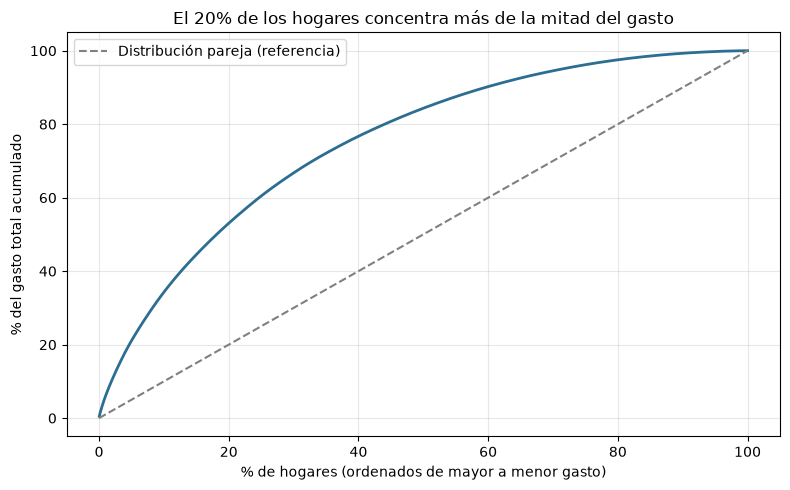

El top 20% de hogares (500 hogares) concentra el 53.0% del gasto total


In [125]:
import matplotlib.pyplot as plt

# ordenamos los hogares de mayor a menor gasto
gasto_ordenado = gasto_por_hogar.sort_values('GASTO_TOTAL', ascending=False).reset_index(drop=True)

# % acumulado de gasto, y % acumulado de hogares
gasto_ordenado['PCT_GASTO_ACUM'] = gasto_ordenado['GASTO_TOTAL'].cumsum() / gasto_ordenado['GASTO_TOTAL'].sum() * 100
gasto_ordenado['PCT_HOGARES_ACUM'] = (gasto_ordenado.index + 1) / len(gasto_ordenado) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gasto_ordenado['PCT_HOGARES_ACUM'], gasto_ordenado['PCT_GASTO_ACUM'], linewidth=2, color='#2c6e91')
ax.plot([0, 100], [0, 100], linestyle='--', color='gray', label='Distribución pareja (referencia)')

ax.set_xlabel('% de hogares (ordenados de mayor a menor gasto)')
ax.set_ylabel('% del gasto total acumulado')
ax.set_title('El 20% de los hogares concentra más de la mitad del gasto')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# el dato exacto para el 20% de los hogares
top_20_pct = int(len(gasto_ordenado) * 0.20)
gasto_top_20 = gasto_ordenado.loc[:top_20_pct-1, 'PCT_GASTO_ACUM'].iloc[-1]
print(f"El top 20% de hogares ({top_20_pct} hogares) concentra el {gasto_top_20:.1f}% del gasto total")

¿Qué departamentos generan más ventas?

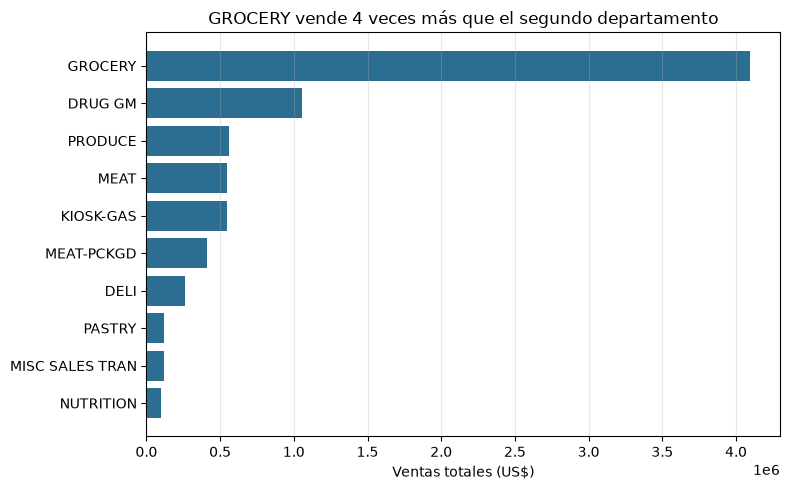

In [126]:
top_10_deptos = ventas_por_depto.head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_10_deptos.index[::-1], top_10_deptos.values[::-1], color='#2c6e91')

ax.set_xlabel('Ventas totales (US$)')
ax.set_title('GROCERY vende 4 veces más que el segundo departamento')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [127]:
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

GROCERY domina sin competencia: casi $4.1M, cuatro veces más que DRUG GM
(el segundo). Después de esos dos, el resto de departamentos vende bastante
menos y están más parejos entre sí.

¿Cómo se distribuye el gasto dentro de una sola compra (canasta)?

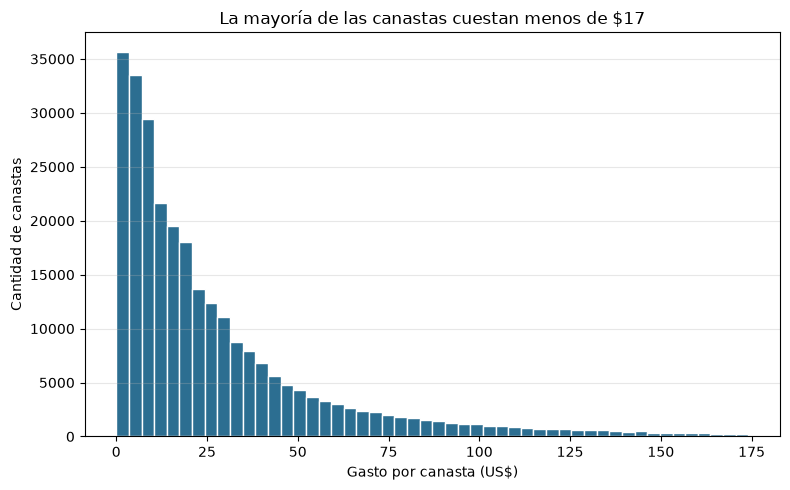

Mediana de gasto por canasta: $17.07
Canasta más cara (dentro del 99%): $174.12


In [128]:
gasto_por_canasta = transaction_completo.groupby('BASKET_ID')['SALES_VALUE'].sum()

fig, ax = plt.subplots(figsize=(8, 5))
# recortamos el 1% más alto para que el histograma no quede aplastado por unos pocos valores extremos
limite = gasto_por_canasta.quantile(0.99)
ax.hist(gasto_por_canasta[gasto_por_canasta <= limite], bins=50, color='#2c6e91', edgecolor='white')

ax.set_xlabel('Gasto por canasta (US$)')
ax.set_ylabel('Cantidad de canastas')
ax.set_title(f'La mayoría de las canastas cuestan menos de ${gasto_por_canasta.median():.0f}')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Mediana de gasto por canasta: ${gasto_por_canasta.median():.2f}")
print(f"Canasta más cara (dentro del 99%): ${limite:.2f}")

La mediana de gasto por canasta es apenas $17, y la mayoría de las compras están
muy por debajo de eso. Hay una cola larga de compras grandes (hasta $174 dentro
del 99%), pero son la excepción — la compra típica es chica y frecuente, no una
mega compra ocasional.

¿El gasto por visita cambia según el tamaño del hogar?

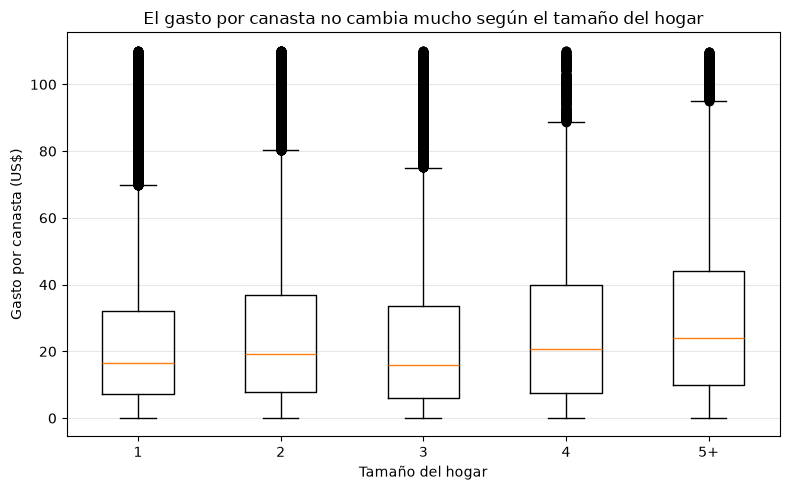

In [129]:
# solo podemos responder esto para el 32% de hogares con demografía disponible
canasta_con_demo = transaction_completo[transaction_completo['HOUSEHOLD_SIZE_DESC'].notna()]
gasto_canasta_demo = canasta_con_demo.groupby(['BASKET_ID', 'HOUSEHOLD_SIZE_DESC'])['SALES_VALUE'].sum().reset_index()

# recortamos outliers extremos para que el boxplot se vea bien
limite = gasto_canasta_demo['SALES_VALUE'].quantile(0.95)
gasto_canasta_demo_recortado = gasto_canasta_demo[gasto_canasta_demo['SALES_VALUE'] <= limite]

orden = sorted(gasto_canasta_demo_recortado['HOUSEHOLD_SIZE_DESC'].unique())

fig, ax = plt.subplots(figsize=(8, 5))
data_por_grupo = [gasto_canasta_demo_recortado[gasto_canasta_demo_recortado['HOUSEHOLD_SIZE_DESC'] == g]['SALES_VALUE'] for g in orden]
ax.boxplot(data_por_grupo, tick_labels=orden)

ax.set_xlabel('Tamaño del hogar')
ax.set_ylabel('Gasto por canasta (US$)')
ax.set_title('El gasto por canasta no cambia mucho según el tamaño del hogar')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Apenas un poco: la mediana sube de $16 (hogares de 1 persona) a $24 (hogares de
5+), pero las distribuciones se superponen casi completamente — un hogar de 1
persona puede gastar lo mismo o más que uno de 5 en una sola visita. El tamaño
del hogar no es un buen predictor del gasto por canasta.



¿En qué departamentos se regala más margen vía descuento?

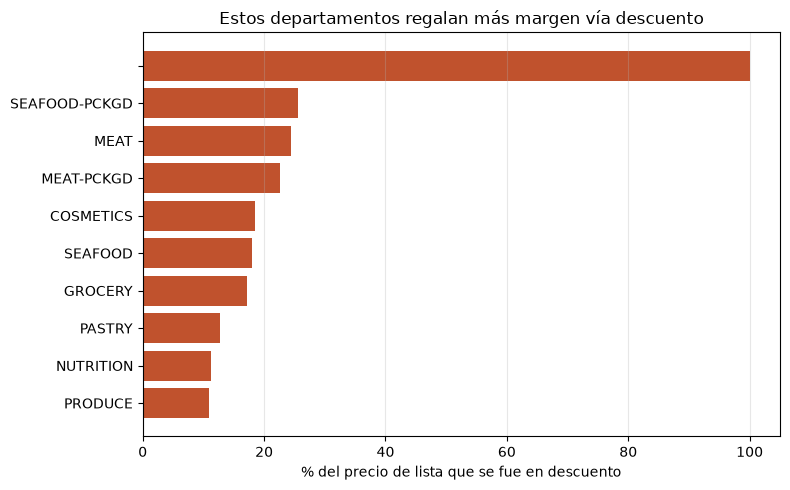

In [130]:
descuento_por_depto = transaction_completo.groupby('DEPARTMENT').agg(
    PRECIO_LISTA_TOTAL=('PRECIO_LISTA', 'sum'),
    DESCUENTO_TOTAL=('DESCUENTO_TOTAL', 'sum')
)

# % del precio de lista que se fue en descuento (descuento viene negativo, por eso el -)
descuento_por_depto['PCT_DESCUENTO'] = -descuento_por_depto['DESCUENTO_TOTAL'] / descuento_por_depto['PRECIO_LISTA_TOTAL'] * 100

# mismo filtro de volumen que usamos antes, para no mostrar ruido de departamentos chiquitos
top_deptos_por_pct_descuento = descuento_por_depto[descuento_por_depto['PRECIO_LISTA_TOTAL'] >= volumen_minimo].sort_values('PCT_DESCUENTO', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_deptos_por_pct_descuento.index[::-1], top_deptos_por_pct_descuento['PCT_DESCUENTO'][::-1], color='#c0522d')

ax.set_xlabel('% del precio de lista que se fue en descuento')
ax.set_title('Estos departamentos regalan más margen vía descuento')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [131]:
descuento_por_depto.loc[top_deptos_por_pct_descuento.index[0]]

PRECIO_LISTA_TOTAL    10306.04
DESCUENTO_TOTAL      -10306.04
PCT_DESCUENTO           100.00
Name:  , dtype: float64

In [132]:
top_deptos_por_pct_descuento.head(1)

,PRECIO_LISTA_TOTAL,DESCUENTO_TOTAL,PCT_DESCUENTO
DEPARTMENT,,,
,10306.04,-10306.04,100.0


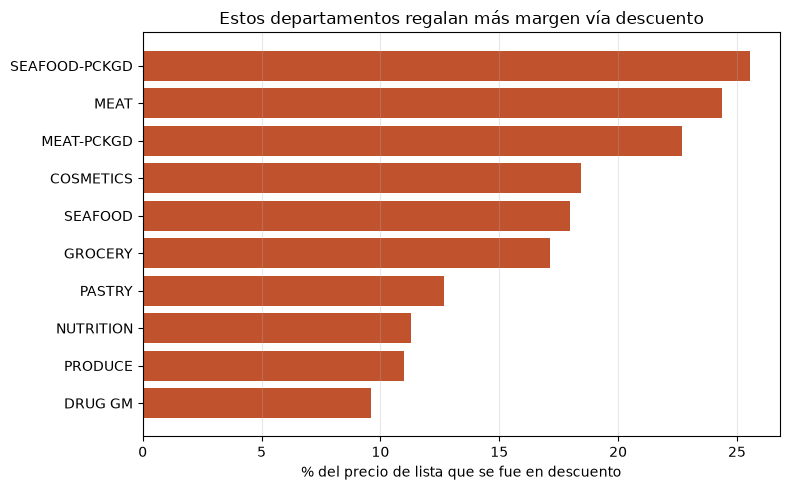

In [135]:
# .str.strip() le quita espacios invisibles antes de comparar, así agarramos tanto '' como ' '
descuento_por_depto_limpio = descuento_por_depto[descuento_por_depto.index.str.strip() != '']

top_deptos_por_pct_descuento = descuento_por_depto_limpio[
    descuento_por_depto_limpio['PRECIO_LISTA_TOTAL'] >= volumen_minimo
].sort_values('PCT_DESCUENTO', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_deptos_por_pct_descuento.index[::-1], top_deptos_por_pct_descuento['PCT_DESCUENTO'][::-1], color='#c0522d')

ax.set_xlabel('% del precio de lista que se fue en descuento')
ax.set_title('Estos departamentos regalan más margen vía descuento')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

Los departamentos de carne y mariscos son los que más descuento regalan (SEAFOOD-PCKGD,
MEAT y MEAT-PCKGD, todos arriba del 22%) — tiene sentido, son productos perecederos
donde la tienda probablemente descuenta para rotar inventario antes de que se dañe.
GROCERY, siendo el departamento que más vende, solo regala 17% en descuento —
relativamente conservador para su tamaño.

In [136]:
hogares_recibieron_campana = campaign_table['household_key'].nunique()
hogares_redimieron_cupon = coupon_redempt['household_key'].nunique()

tasa_redencion = hogares_redimieron_cupon / hogares_recibieron_campana * 100

print(f"Hogares que recibieron alguna campaña: {hogares_recibieron_campana:,}")
print(f"Hogares que redimieron al menos un cupón: {hogares_redimieron_cupon:,}")
print(f"Tasa de redención: {tasa_redencion:.1f}%")

Hogares que recibieron alguna campaña: 1,584
Hogares que redimieron al menos un cupón: 434
Tasa de redención: 27.4%


In [137]:
costo_total_cupones = -transaction_completo['COUPON_DISC'].sum() - transaction_completo['COUPON_MATCH_DISC'].sum()
costo_total_descuento_retail = -transaction_completo['RETAIL_DISC'].sum()

print(f"Costo total en descuentos de cupón (COUPON_DISC + COUPON_MATCH_DISC): ${costo_total_cupones:,.2f}")
print(f"Costo total en descuento de góndola (RETAIL_DISC): ${costo_total_descuento_retail:,.2f}")

Costo total en descuentos de cupón (COUPON_DISC + COUPON_MATCH_DISC): $50,187.35
Costo total en descuento de góndola (RETAIL_DISC): $1,398,334.84


Solo el 27.4% de los hogares que recibieron alguna campaña llegó a redimir un
cupón (434 de 1,584). Y en plata: la tienda gasta $1.4M en descuento general de
góndola (RETAIL_DISC, para todo el mundo) contra apenas $50K en cupones dirigidos
por campaña — casi 28 veces más. O sea que la mecánica "cara" y personalizada
(campañas + cupones) mueve poco dinero real y tiene una tasa de uso baja, mientras
que casi todo el descuento se va por la vía genérica de góndola, sin dirigir a
nadie en particular.

## Recomendación final

Con los datos que tenemos, revisaríamos primero a qué hogares se les envían las
campañas antes de seguir invirtiendo en ellas. Los hogares que las recibieron ya
gastaban, en promedio, cinco veces más que los demás incluso antes de la campaña.
Además, solo se redimió el 27.4% de los cupones. Esto nos hace pensar que
podríamos estar ofreciendo cupones a personas que probablemente iban a comprar
de todos modos.

También valdría la pena comparar esta inversión con el descuento general en
góndola: se gastaron $50K en cupones, frente a $1.4M en descuentos generales.
Pero no recomendaríamos mover todo el presupuesto todavía. Como los datos no
incluyen un grupo de control, no podemos saber cuánto de las compras se debió
realmente a la campaña. Lo más útil sería probar una nueva selección de hogares
y medir sus resultados antes de decidir dónde conviene invertir más.